## Section 1: Import Libraries

In [1]:
# ============================================
# Section 1: Import Libraries
# ============================================

# pandas -> used to load and work with tabular data (like Excel/CSV)
import pandas as pd

# numpy -> used for numerical operations (arrays, math)
import numpy as np

# matplotlib and seaborn -> used to create graphs for EDA
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split -> splits our data into training and testing parts
from sklearn.model_selection import train_test_split

# OneHotEncoder -> converts text categories (like Industry) into numbers
from sklearn.preprocessing import OneHotEncoder

# LinearRegression and RandomForestRegressor -> our two ML models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics -> to check how good our model is
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# joblib -> used to save our trained model to a file
import joblib

# This line makes our graphs look a bit nicer
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 2: Load Dataset

In [2]:
# ============================================
# Section 2: Load Dataset
# ============================================

# Load the CSV file into a pandas DataFrame
# A DataFrame is just a table, similar to an Excel sheet
df = pd.read_csv("user_level_ai_adoption.csv")

# Display the first 5 rows to check if data loaded correctly
df.head()

,User_ID,Industry,Job_Role,Location,Experience_Years,Primary_AI_Tool,Daily_Token_Usage,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Adoption_Date
0,USR-690F519F,Software Development,Software Engineer,Europe,13,ChatGPT (OpenAI),10640,2,19.3,2023-02-28
1,USR-72A07ABB,Software Development,Software Engineer,North America,9,Claude (Anthropic),8535,1,5.0,2023-08-17
2,USR-CBCEAA19,Finance,Accountant,Asia-Pacific,21,Claude (Anthropic),9585,1,13.4,2023-11-02
3,USR-03B7DC34,Healthcare,Clinical Admin,North America,20,Perplexity,7094,2,9.9,2025-06-06
4,USR-CA8308D1,Marketing,Social Media Manager,Asia-Pacific,14,ChatGPT (OpenAI),9277,1,12.8,2023-04-03


## Section 3: Dataset Information

In [3]:
# ============================================
# Section 3: Dataset Information
# ============================================

# Shape tells us (number of rows, number of columns)
print("Shape of dataset:", df.shape)

# info() shows column names, data types, and non-null counts
print("\nDataset Info:")
df.info()

# Check how many missing (empty) values are in each column
print("\nMissing values in each column:")
print(df.isnull().sum())

# Check how many duplicate rows exist
print("\nNumber of duplicate rows:", df.duplicated().sum())

# describe() gives basic statistics (mean, min, max, etc.) for numeric columns
print("\nStatistical Summary:")
df.describe()

Shape of dataset: (15000, 10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    15000 non-null  object 
 1   Industry                   15000 non-null  object 
 2   Job_Role                   15000 non-null  object 
 3   Location                   15000 non-null  object 
 4   Experience_Years           15000 non-null  int64  
 5   Primary_AI_Tool            15000 non-null  object 
 6   Daily_Token_Usage          15000 non-null  int64  
 7   Tasks_Automated_Per_Week   15000 non-null  int64  
 8   Productivity_Gain_Percent  15000 non-null  float64
 9   Adoption_Date              15000 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 1.1+ MB

Missing values in each column:
User_ID                      0
Industry                     0
Job_Role          

,Experience_Years,Daily_Token_Usage,Tasks_Automated_Per_Week,Productivity_Gain_Percent
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,13.013400,8958.312200,1.913267,11.215827
std,7.215642,8449.890624,1.176196,11.578100
min,1.000000,411.000000,1.000000,0.300000
25%,7.000000,3049.000000,1.000000,3.600000
50%,13.000000,7336.000000,2.000000,8.100000
75%,19.000000,11740.250000,3.000000,14.800000
max,25.000000,58989.000000,12.000000,84.900000


## Section 4: Exploratory Data Analysis (EDA)


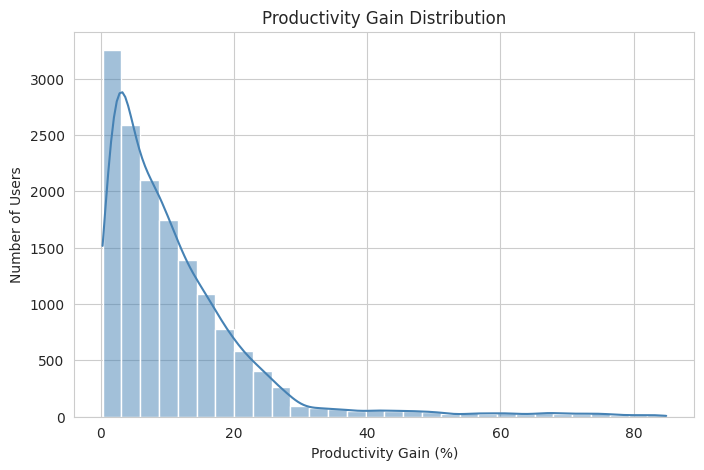

In [4]:
# ============================================
# Section 4: Exploratory Data Analysis (EDA)
# ============================================

# ---- Graph 1: Productivity Gain Distribution ----
plt.figure(figsize=(8, 5))
sns.histplot(df["Productivity_Gain_Percent"], bins=30, kde=True, color="steelblue")
plt.title("Productivity Gain Distribution")
plt.xlabel("Productivity Gain (%)")
plt.ylabel("Number of Users")
plt.show()

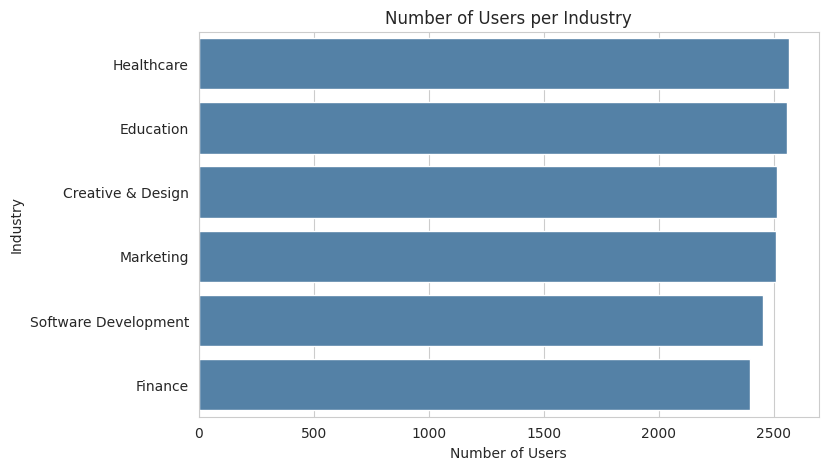

In [5]:
# ---- Graph 2: Industry Count ----
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="Industry", order=df["Industry"].value_counts().index, color="steelblue")
plt.title("Number of Users per Industry")
plt.xlabel("Number of Users")
plt.ylabel("Industry")
plt.show()

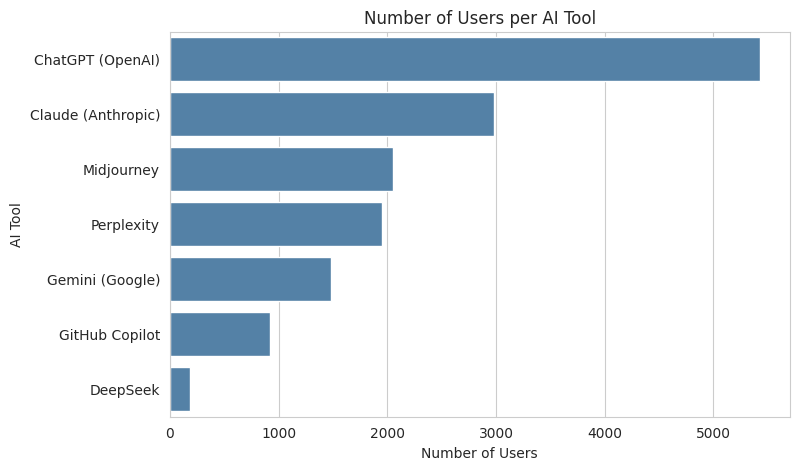

In [6]:
# ---- Graph 3: AI Tool Count ----
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="Primary_AI_Tool", order=df["Primary_AI_Tool"].value_counts().index, color="steelblue")
plt.title("Number of Users per AI Tool")
plt.xlabel("Number of Users")
plt.ylabel("AI Tool")
plt.show()

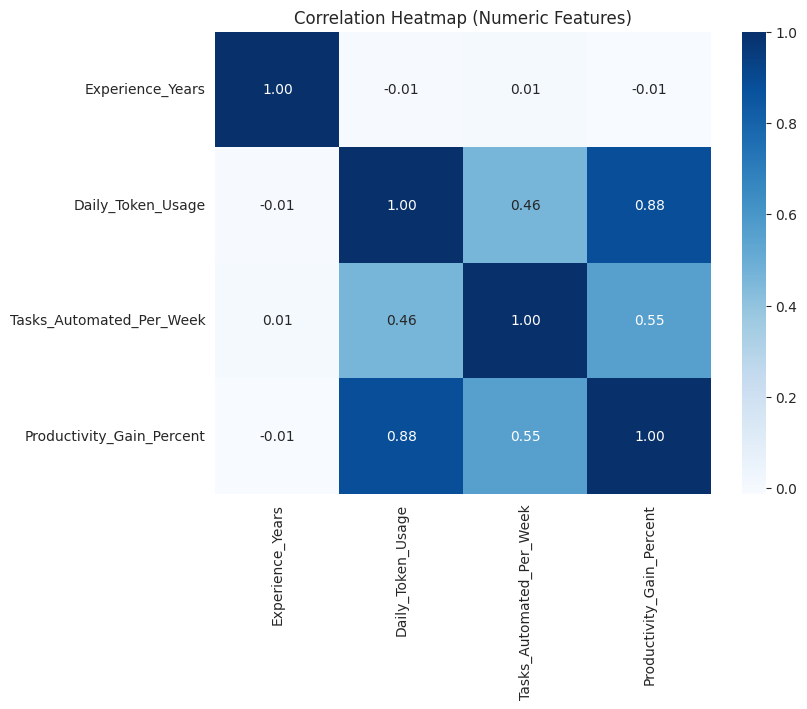

In [7]:
# ---- Graph 4: Correlation Heatmap ----
numeric_columns = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_columns.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

## Section 5: Data Cleaning

In [8]:
# ============================================
# Section 5: Data Cleaning
# ============================================

# Step 1: Handle missing values (if any)
df = df.dropna()

# Step 2: Remove duplicate rows (if any)
df = df.drop_duplicates()

# Step 3: Confirm cleaning worked
print("Shape after cleaning:", df.shape)
print("Missing values after cleaning:\n", df.isnull().sum())
print("Duplicate rows after cleaning:", df.duplicated().sum())

Shape after cleaning: (15000, 10)
Missing values after cleaning:
 User_ID                      0
Industry                     0
Job_Role                     0
Location                     0
Experience_Years             0
Primary_AI_Tool              0
Daily_Token_Usage            0
Tasks_Automated_Per_Week     0
Productivity_Gain_Percent    0
Adoption_Date                0
dtype: int64
Duplicate rows after cleaning: 0


## Section 6: Feature Engineering

We extract `Year` and `Month` from `Adoption_Date`, then check if they actually show
a real relationship with `Productivity_Gain_Percent` before deciding to use them.

In [9]:
# ============================================
# Section 6: Feature Engineering
# ============================================

# Step 1: Convert Adoption_Date column to a proper date format
df["Adoption_Date"] = pd.to_datetime(df["Adoption_Date"])

# Step 2: Extract Year and Month from the date
df["Adoption_Year"] = df["Adoption_Date"].dt.year
df["Adoption_Month"] = df["Adoption_Date"].dt.month

# Step 3: Check if Year and Month actually relate to Productivity Gain
print("Average Productivity Gain by Year:")
print(df.groupby("Adoption_Year")["Productivity_Gain_Percent"].mean())

print("\nAverage Productivity Gain by Month:")
print(df.groupby("Adoption_Month")["Productivity_Gain_Percent"].mean())

# Conclusion: The averages are almost flat across years and months,
# so these features do NOT meaningfully help predict productivity gain.
# We will NOT include them in our model (kept simple, evidence-based decision).

Average Productivity Gain by Year:
Adoption_Year
2021    11.362369
2022    11.121619
2023    11.350414
2024    11.111348
2025    11.028314
2026    11.158674
Name: Productivity_Gain_Percent, dtype: float64

Average Productivity Gain by Month:
Adoption_Month
1     10.479680
2     11.402331
3     11.266403
4     11.544751
5     11.065446
6     11.286557
7     11.486221
8     10.987603
9     11.500334
10    11.220161
11    11.187730
12    11.208564
Name: Productivity_Gain_Percent, dtype: float64


## Section 7: Feature Selection

In [10]:
# ============================================
# Section 7: Feature Selection (UPDATED — Location removed)
# ============================================
# We tested Location's contribution using feature importance and found it
# explains less than 0.3% of the prediction (see Section 12b). Asking users
# their location also felt unnecessary for this use case, so we drop it.
# We exclude User_ID (no predictive value) and Adoption_Year/Month
# (tested in Section 6, no meaningful pattern).

X = df[[
    "Industry",
    "Job_Role",
    "Experience_Years",
    "Primary_AI_Tool",
    "Daily_Token_Usage",
    "Tasks_Automated_Per_Week"
]]

y = df["Productivity_Gain_Percent"]

print("Selected input features:", list(X.columns))
print("Target variable:", y.name)

Selected input features: ['Industry', 'Job_Role', 'Experience_Years', 'Primary_AI_Tool', 'Daily_Token_Usage', 'Tasks_Automated_Per_Week']
Target variable: Productivity_Gain_Percent


## Section 8: Encoding Categorical Variables


In [11]:
# ============================================
# Section 8: Encoding Categorical Variables (UPDATED — no Location)
# ============================================
categorical_columns = ["Industry", "Job_Role", "Primary_AI_Tool"]
numeric_columns = ["Experience_Years", "Daily_Token_Usage", "Tasks_Automated_Per_Week"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(X[categorical_columns])
encoded_columns = encoder.get_feature_names_out(categorical_columns)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns)

X_encoded = pd.concat([X[numeric_columns].reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (15000, 38)


,Experience_Years,Daily_Token_Usage,Tasks_Automated_Per_Week,Industry_Creative & Design,Industry_Education,Industry_Finance,Industry_Healthcare,Industry_Marketing,Industry_Software Development,Job_Role_Accountant,...,Job_Role_Teacher,Job_Role_UI/UX Designer,Job_Role_Video Editor,Primary_AI_Tool_ChatGPT (OpenAI),Primary_AI_Tool_Claude (Anthropic),Primary_AI_Tool_DeepSeek,Primary_AI_Tool_Gemini (Google),Primary_AI_Tool_GitHub Copilot,Primary_AI_Tool_Midjourney,Primary_AI_Tool_Perplexity
0,13,10640,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,8535,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,21,9585,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,20,7094,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,14,9277,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Section 9: Train-Test Split

In [12]:
# ============================================
# Section 9: Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (12000, 38)
Testing set size: (3000, 38)


## Section 10: Train Linear Regression

In [13]:
# ============================================
# Section 10: Train Linear Regression
# ============================================
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance:")
print(f"MAE  : {linear_mae:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R2   : {linear_r2:.2f}")

Linear Regression Performance:
MAE  : 3.79
RMSE : 5.30
R2   : 0.80


## Section 11: Train Random Forest Regressor

In [14]:
# ============================================
# Section 11: Train Random Forest Regressor
# ============================================
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)
rf_predictions = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance:")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R2   : {rf_r2:.2f}")

Random Forest Performance:
MAE  : 2.84
RMSE : 4.20
R2   : 0.87


## Section 12: Model Comparison

In [15]:
# ============================================
# Section 12: Model Comparison
# ============================================
comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

print("Model Comparison Table:")
print(comparison_table)

best_model = random_forest_model if rf_r2 > linear_r2 else linear_model
best_model_name = "Random Forest" if rf_r2 > linear_r2 else "Linear Regression"
print("\nBest Model Selected:", best_model_name)

Model Comparison Table:
               Model       MAE      RMSE  R2 Score
0  Linear Regression  3.791918  5.301408  0.799724
1      Random Forest  2.843266  4.197019  0.874476

Best Model Selected: Random Forest


Top 10 Most Important Features:
Tasks_Automated_Per_Week              0.620265
Daily_Token_Usage                     0.320208
Experience_Years                      0.021972
Primary_AI_Tool_ChatGPT (OpenAI)      0.002366
Primary_AI_Tool_Claude (Anthropic)    0.001884
Primary_AI_Tool_Perplexity            0.001732
Primary_AI_Tool_Gemini (Google)       0.001589
Job_Role_DevOps Engineer              0.001576
Job_Role_Data Scientist               0.001560
Job_Role_QA Tester                    0.001515
dtype: float64


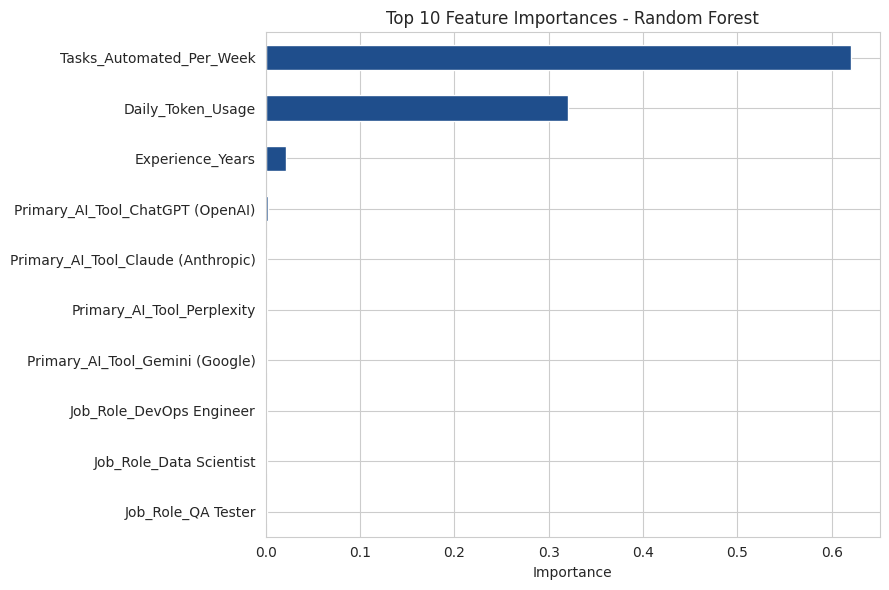


5-Fold Cross-Validation R2 Scores: [0.88409871 0.88231837 0.87902952 0.87689195 0.88701246]
Mean CV R2: 0.8819
Standard Deviation: 0.0036


In [16]:
# ============================================
# Section 12b: Feature Importance & Cross-Validation
# ============================================
from sklearn.model_selection import cross_val_score

importances = pd.Series(
    random_forest_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

print("Top 10 Most Important Features:")
print(importances.head(10))

plt.figure(figsize=(9, 6))
importances.head(10).sort_values().plot(kind="barh", color="#1F4E8C")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

cv_scores = cross_val_score(random_forest_model, X_encoded, y, cv=5, scoring="r2")
print("\n5-Fold Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

## Section 13: Save Model

In [17]:
# ============================================
# Section 13: Save Model
# ============================================
joblib.dump(best_model, "best_model.pkl", compress=3)
joblib.dump(encoder, "encoder.pkl")

print("Model saved as: best_model.pkl")
print("Encoder saved as: encoder.pkl")
print("Best model used:", best_model_name)

Model saved as: best_model.pkl
Encoder saved as: encoder.pkl
Best model used: Random Forest


## Section 14: Sample Prediction


In [18]:
# ============================================
# Section 14: Sample Prediction
# ============================================
sample_index = 0
sample_input = X_test.iloc[[sample_index]]
actual_value = y_test.iloc[sample_index]

loaded_model = joblib.load("best_model.pkl")
predicted_value = loaded_model.predict(sample_input)[0]

print("Sample Prediction Check")
print("------------------------")
print(f"Actual Productivity Gain    : {actual_value} %")
print(f"Predicted Productivity Gain : {predicted_value:.2f} %")
print(f"Difference                  : {abs(actual_value - predicted_value):.2f} %")


Sample Prediction Check
------------------------
Actual Productivity Gain    : 2.6 %
Predicted Productivity Gain : 4.72 %
Difference                  : 2.12 %


In [19]:
# ================================================================
# Run & Test the Streamlit App in Google Colab using ngrok
# (Simplified - authtoken hidden using getpass)
# ================================================================

# ---- Step 1: Install everything needed ----
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 45.5 MB/s eta 0:00:00


In [20]:
# ---- Step 2: Enter your ngrok authtoken (hidden input, not saved anywhere) ----
# Get your free token from: https://dashboard.ngrok.com/get-started/your-authtoken
from getpass import getpass
from pyngrok import ngrok

ngrok.kill()  # close any old tunnels first
ngrok.set_auth_token(getpass("Paste your ngrok authtoken: "))

Paste your ngrok authtoken: ··········


In [21]:
 #---- Step 3: Run the app and open the tunnel ----
import subprocess, time

subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
time.sleep(6)  # give streamlit a moment to start

public_url = ngrok.connect(8501)
print("Your app is live at:", public_url)

Your app is live at: NgrokTunnel: "https://divided-unearth-swarm.ngrok-free.dev" -> "http://localhost:8501"


In [22]:
import sklearn, pandas, joblib, streamlit
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)
print("streamlit:", streamlit.__version__)

scikit-learn: 1.6.1
pandas: 2.2.2
joblib: 1.5.3
streamlit: 1.60.0


## Summary

- We compared **Linear Regression** and **Random Forest Regressor** using MAE, RMSE, and R2 Score.
- **Random Forest** performed better on all three metrics and was saved as our final model.
- The trained model (`best_model.pkl`) and encoder (`encoder.pkl`) are used by our
  Streamlit web app (`app.py`) to make live predictions for new users.